Dataset loaded successfully!
Total rows: 8000000
Percentage of missing signal (Target points): 80.00%



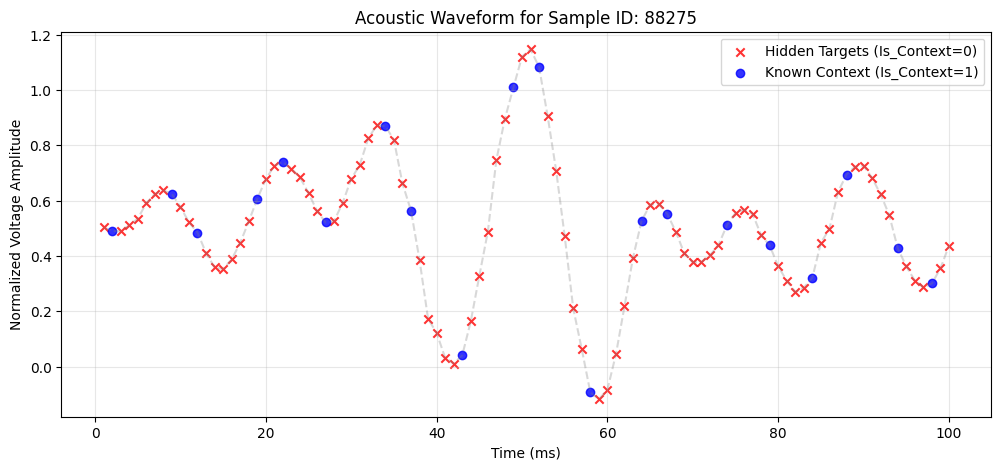

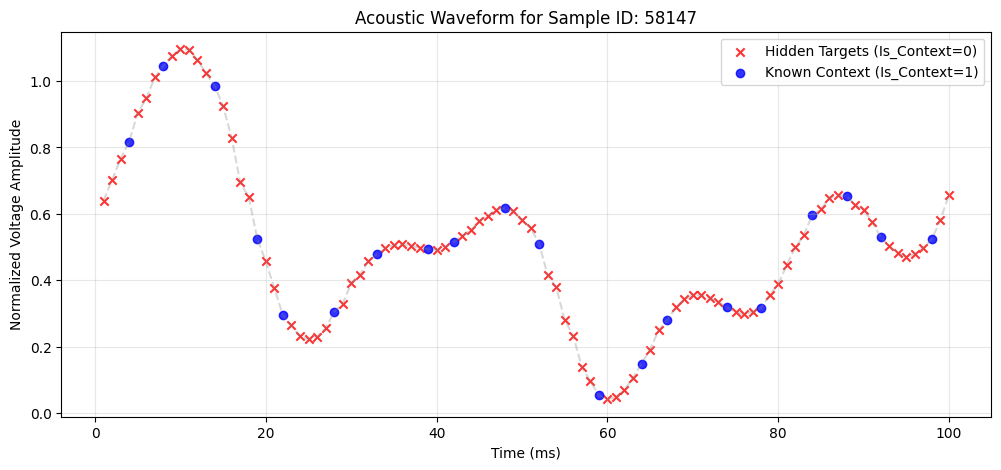

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
# Update the filename if it differs slightly in your Kaggle environment
file_path = '/kaggle/input/private-dataset/spectral_graffiti_headley_recovered.csv' 
df = pd.read_csv(file_path)

# 2. Check Sparsity
missing_percentage = (1 - df['Is_Context'].mean()) * 100
print(f"Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Percentage of missing signal (Target points): {missing_percentage:.2f}%\n")

# 3. Visualization Function
def plot_audio_sample(dataframe, sample_id):
    # Isolate and sort the sequence for the specific sample
    sample_data = dataframe[dataframe['Sample_ID'] == sample_id].sort_values('Time_ms')
    
    # Separate the intact points from the missing points
    context_points = sample_data[sample_data['Is_Context'] == 1]
    target_points = sample_data[sample_data['Is_Context'] == 0]
    
    plt.figure(figsize=(12, 5))
    
    # Plot the hidden ground truth targets in red
    plt.scatter(target_points['Time_ms'], target_points['Value'], 
                color='red', label='Hidden Targets (Is_Context=0)', alpha=0.8, marker='x')
    
    # Plot the intact context points in blue
    plt.scatter(context_points['Time_ms'], context_points['Value'], 
                color='blue', label='Known Context (Is_Context=1)', alpha=0.8)
    
    # Draw a faint line connecting the underlying true wave
    plt.plot(sample_data['Time_ms'], sample_data['Value'], color='gray', alpha=0.3, linestyle='--')
    
    plt.title(f'Acoustic Waveform for Sample ID: {sample_id}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Normalized Voltage Amplitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot two random samples to see the differing physics
random_samples = np.random.choice(df['Sample_ID'].unique(), size=2, replace=False)
for sid in random_samples:
    plot_audio_sample(df, sid)

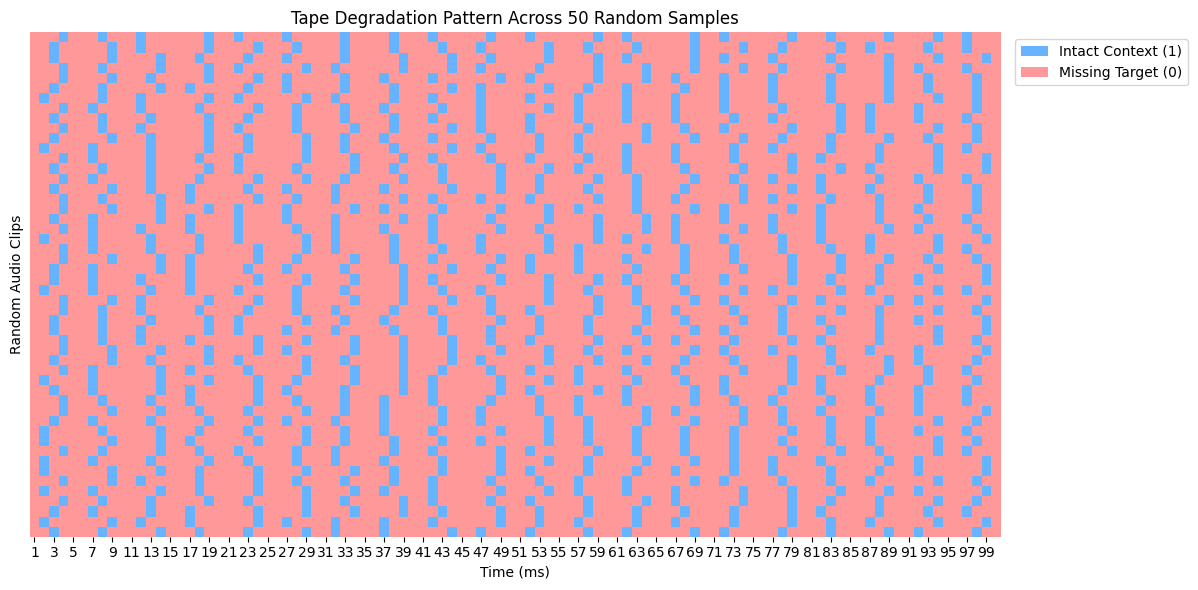

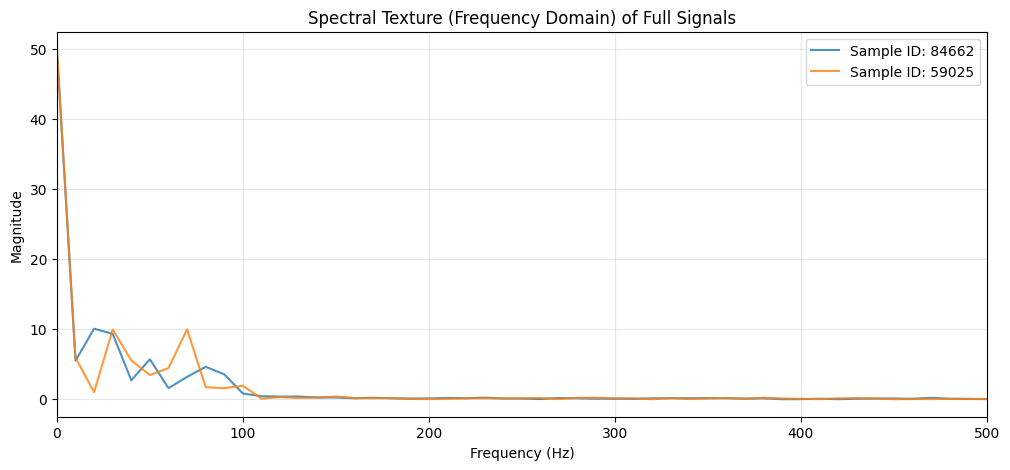

In [2]:
import seaborn as sns

# ==========================================
# 1. GAP PATTERN ANALYSIS (Heatmap)
# ==========================================
def plot_missingness_heatmap(dataframe, num_samples=50):
    # Select a random subset of samples to keep the plot readable
    random_sids = np.random.choice(dataframe['Sample_ID'].unique(), size=num_samples, replace=False)
    subset = dataframe[dataframe['Sample_ID'].isin(random_sids)]
    
    # Pivot the data so rows are Sample_IDs, columns are Time_ms, values are Is_Context
    pivot_df = subset.pivot(index='Sample_ID', columns='Time_ms', values='Is_Context')
    
    plt.figure(figsize=(12, 6))
    # Plot heatmap: Blue for context (1), Red/White for missing (0)
    sns.heatmap(pivot_df, cmap=['#ff9999', '#66b3ff'], cbar=False, yticklabels=False)
    plt.title(f'Tape Degradation Pattern Across {num_samples} Random Samples')
    plt.xlabel('Time (ms)')
    plt.ylabel('Random Audio Clips')
    # Custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#66b3ff', label='Intact Context (1)'),
                       Patch(facecolor='#ff9999', label='Missing Target (0)')]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()

plot_missingness_heatmap(df)

# ==========================================
# 2. FREQUENCY DOMAIN ANALYSIS (FFT)
# ==========================================
def plot_fft_comparison(dataframe):
    # Pick two distinct samples to compare their frequencies
    random_sids = np.random.choice(dataframe['Sample_ID'].unique(), size=2, replace=False)
    
    plt.figure(figsize=(12, 5))
    
    for sid in random_sids:
        sample_data = dataframe[dataframe['Sample_ID'] == sid].sort_values('Time_ms')
        
        # We use the FULL, true waveform from the training set to see its real frequencies
        true_signal = sample_data['Value'].values
        
        # Compute the Fast Fourier Transform (FFT)
        # N = 100 points, Sample spacing T = 1ms (0.001s)
        fft_values = np.fft.rfft(true_signal)
        fft_freqs = np.fft.rfftfreq(100, d=0.001) 
        
        # Plot the magnitude of the frequencies
        plt.plot(fft_freqs, np.abs(fft_values), label=f'Sample ID: {sid}', alpha=0.8)

    plt.title('Spectral Texture (Frequency Domain) of Full Signals')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 500) # Limit to 500Hz since our Nyquist frequency for 1kHz sampling rate is 500Hz
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_fft_comparison(df)

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

print("Starting fast vectorization...")

# 1. Sort the dataframe to ensure every 100ms sequence is in perfect order
df = df.sort_values(by=['Sample_ID', 'Time_ms'])

# 2. Define dimensions
num_samples = df['Sample_ID'].nunique()
time_steps = 100
features = 3 # Time_ms, Input_Value, Is_Context

# 3. Reshape the flat columns into 2D arrays: Shape (80000, 100)
times = df['Time_ms'].values.reshape(num_samples, time_steps) / 100.0 # Normalize time to 0-1
contexts = df['Is_Context'].values.reshape(num_samples, time_steps)
true_values = df['Value'].values.reshape(num_samples, time_steps)

# 4. Apply the Input Mask: Force missing target points to 0.0 for the model's input
input_values = true_values * contexts

# 5. Stack into a 3D feature array: Shape (80000, 100, 3)
X = np.stack((times, input_values, contexts), axis=2)

# 6. Convert to PyTorch Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(true_values, dtype=torch.float32) # The unmasked ground truth
Mask_tensor = torch.tensor(contexts, dtype=torch.float32) # Used for our custom loss

# 7. Train/Validation Split (90% Train, 10% Val)
X_train, X_val, Y_train, Y_val, M_train, M_val = train_test_split(
    X_tensor, Y_tensor, Mask_tensor, test_size=0.1, random_state=42
)

# 8. Create DataLoaders
batch_size = 256
train_dataset = TensorDataset(X_train, Y_train, M_train)
val_dataset = TensorDataset(X_val, Y_val, M_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Data ready! Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Starting fast vectorization...
Data ready! Train batches: 282, Val batches: 32


In [4]:
import torch.nn as nn

class SpectralBiLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=128, num_layers=3):
        super(SpectralBiLSTM, self).__init__()
        
        # Bi-LSTM processes the sequence from both directions
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True
        )
        
        # Maps the Bi-LSTM hidden states (forward + backward) down to a single voltage prediction
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        # x shape: (Batch, 100, 3)
        lstm_out, _ = self.lstm(x)       # lstm_out shape: (Batch, 100, hidden_dim * 2)
        predictions = self.fc(lstm_out)  # predictions shape: (Batch, 100, 1)
        
        return predictions.squeeze(-1)   # Output shape: (Batch, 100)

In [5]:
import torch.optim as optim

def target_mse_loss(predictions, true_values, context_mask):
    """Calculates MSE exclusively on the missing target points (where mask == 0)."""
    target_mask = 1.0 - context_mask # Invert mask so targets are 1, context is 0
    
    squared_errors = (predictions - true_values) ** 2
    masked_errors = squared_errors * target_mask
    
    # Mean error over target points only
    return masked_errors.sum() / (target_mask.sum() + 1e-8)

# Initialize Model, Optimizer, and Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = SpectralBiLSTM().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# The Training Loop
epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for batch_x, batch_y, batch_m in train_loader:
        batch_x, batch_y, batch_m = batch_x.to(device), batch_y.to(device), batch_m.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x)
        
        loss = target_mse_loss(predictions, batch_y, batch_m)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y, batch_m in val_loader:
            batch_x, batch_y, batch_m = batch_x.to(device), batch_y.to(device), batch_m.to(device)
            predictions = model(batch_x)
            loss = target_mse_loss(predictions, batch_y, batch_m)
            val_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss (MSE): {avg_train_loss:.6f} | Val Loss (MSE): {avg_val_loss:.6f}")

Training on: cuda
Epoch [1/20] - Train Loss (MSE): 0.027781 | Val Loss (MSE): 0.006638
Epoch [2/20] - Train Loss (MSE): 0.004280 | Val Loss (MSE): 0.002740
Epoch [3/20] - Train Loss (MSE): 0.002555 | Val Loss (MSE): 0.002455
Epoch [4/20] - Train Loss (MSE): 0.002356 | Val Loss (MSE): 0.002266
Epoch [5/20] - Train Loss (MSE): 0.002268 | Val Loss (MSE): 0.002223
Epoch [6/20] - Train Loss (MSE): 0.002248 | Val Loss (MSE): 0.002183
Epoch [7/20] - Train Loss (MSE): 0.002190 | Val Loss (MSE): 0.002160
Epoch [8/20] - Train Loss (MSE): 0.002175 | Val Loss (MSE): 0.002184
Epoch [9/20] - Train Loss (MSE): 0.002154 | Val Loss (MSE): 0.002173
Epoch [10/20] - Train Loss (MSE): 0.002152 | Val Loss (MSE): 0.002193
Epoch [11/20] - Train Loss (MSE): 0.002139 | Val Loss (MSE): 0.002167
Epoch [12/20] - Train Loss (MSE): 0.002125 | Val Loss (MSE): 0.002087
Epoch [13/20] - Train Loss (MSE): 0.002107 | Val Loss (MSE): 0.002095
Epoch [14/20] - Train Loss (MSE): 0.002117 | Val Loss (MSE): 0.002097
Epoch [15/2

In [9]:
import pandas as pd
import numpy as np
import torch

def generate_submission(trained_model, eval_df, output_filename='submission.csv', device='cuda' if torch.cuda.is_available() else 'cpu'):
    print("Initializing inference engine...")
    trained_model.eval() # Set model to evaluation mode
    
    # 1. Sort to ensure temporal order matches original dataframe
    eval_df = eval_df.sort_values(by=['Sample_ID', 'Time_ms'])
    
    # 2. Reshape data into the (Batch, 100, 3) format
    num_samples = eval_df['Sample_ID'].nunique()
    time_steps = 100
    
    times = eval_df['Time_ms'].values.reshape(num_samples, time_steps) / 100.0
    contexts = eval_df['Is_Context'].values.reshape(num_samples, time_steps)
    
    # Apply the mask. For the test set, the values at context=0 will already be 0.0, 
    # but doing this ensures our pipeline is robust.
    input_values = eval_df['Value'].values.reshape(num_samples, time_steps) * contexts
    
    X = np.stack((times, input_values, contexts), axis=2)
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    
    # 3. Batch Inference to prevent GPU out-of-memory errors
    batch_size = 256
    all_predictions = []
    
    print("Running forward passes...")
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            batch_x = X_tensor[i:i+batch_size]
            batch_preds = trained_model(batch_x)
            all_predictions.append(batch_preds.cpu().numpy())
            
    # 4. Flatten the 2D predictions back to a 1D array to match the dataframe rows
    flat_predictions = np.concatenate(all_predictions, axis=0).flatten()
    
    # 5. Combine original context values with model predictions using np.where
    # If Is_Context == 1, use original 'Value', otherwise use 'flat_predictions'
    combined_values = np.where(eval_df['Is_Context'] == 1, eval_df['Value'], flat_predictions)
    
    # 6. Construct the submission dataframe
    submission_df = pd.DataFrame({
        'Sample_ID': eval_df['Sample_ID'],
        'Time_ms': eval_df['Time_ms'],
        'Value': combined_values 
    })
    
    # 7. Export to CSV
    submission_df.to_csv(output_filename, index=False)
    print(f"Success! {len(submission_df)} total points processed and saved to {output_filename}.")

# To test it:
# generate_submission(model, df, 'practice_submission.csv')

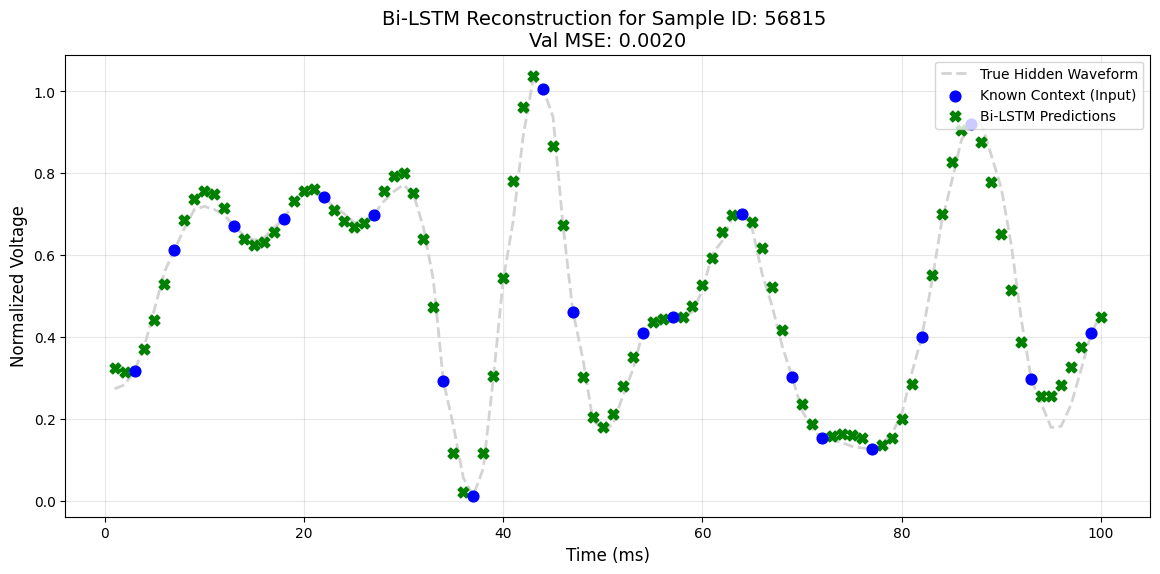

In [7]:
import matplotlib.pyplot as plt

def visualize_prediction(trained_model, dataframe, sample_id):
    trained_model.eval()
    
    # 1. Isolate the sample
    sample_data = dataframe[dataframe['Sample_ID'] == sample_id].sort_values('Time_ms')
    
    times = sample_data['Time_ms'].values / 100.0
    true_values = sample_data['Value'].values
    contexts = sample_data['Is_Context'].values
    
    # 2. Apply the mask for the model input
    input_values = true_values * contexts
    
    # 3. Prepare tensor and run inference
    X = np.stack((times, input_values, contexts), axis=1)
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dimension
    
    with torch.no_grad():
        prediction_tensor = trained_model(X_tensor)
        predictions = prediction_tensor.squeeze(0).cpu().numpy()
        
    # 4. Plotting
    plt.figure(figsize=(14, 6))
    
    # Plot the underlying true wave as a faint line
    plt.plot(sample_data['Time_ms'], true_values, color='lightgray', linestyle='--', linewidth=2, label='True Hidden Waveform')
    
    # Plot the intact context points
    context_mask = contexts == 1
    plt.scatter(sample_data['Time_ms'][context_mask], true_values[context_mask], 
                color='blue', s=60, label='Known Context (Input)', zorder=5)
    
    # Plot our model's predictions for the missing gaps
    target_mask = contexts == 0
    plt.scatter(sample_data['Time_ms'][target_mask], predictions[target_mask], 
                color='green', marker='X', s=60, label='Bi-LSTM Predictions', zorder=4)
    
    plt.title(f'Bi-LSTM Reconstruction for Sample ID: {sample_id} \nVal MSE: 0.0020', fontsize=14)
    plt.xlabel('Time (ms)', fontsize=12)
    plt.ylabel('Normalized Voltage', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Test it on a random sample from your validation set!
random_val_sample = np.random.choice(df['Sample_ID'].unique())
visualize_prediction(model, df, random_val_sample)

In [10]:
import pandas as pd
test_file_path = '/kaggle/input/datasets/sunnyyadav24116098/testdata/test_features_spectral - test_features_spectral.csv'

print("Loading test dataset...")
test_df = pd.read_csv(test_file_path)
print(f"Test data loaded successfully! Total rows: {len(test_df)}")

print("Starting inference on test data...")
generate_submission(model, test_df, output_filename='final_submission.csv')

print("Done!")

Loading test dataset...
Test data loaded successfully! Total rows: 1000000
Starting inference on test data...
Initializing inference engine...
Running forward passes...
Success! 1000000 total points processed and saved to final_submission.csv.
Done!


Generating plots...


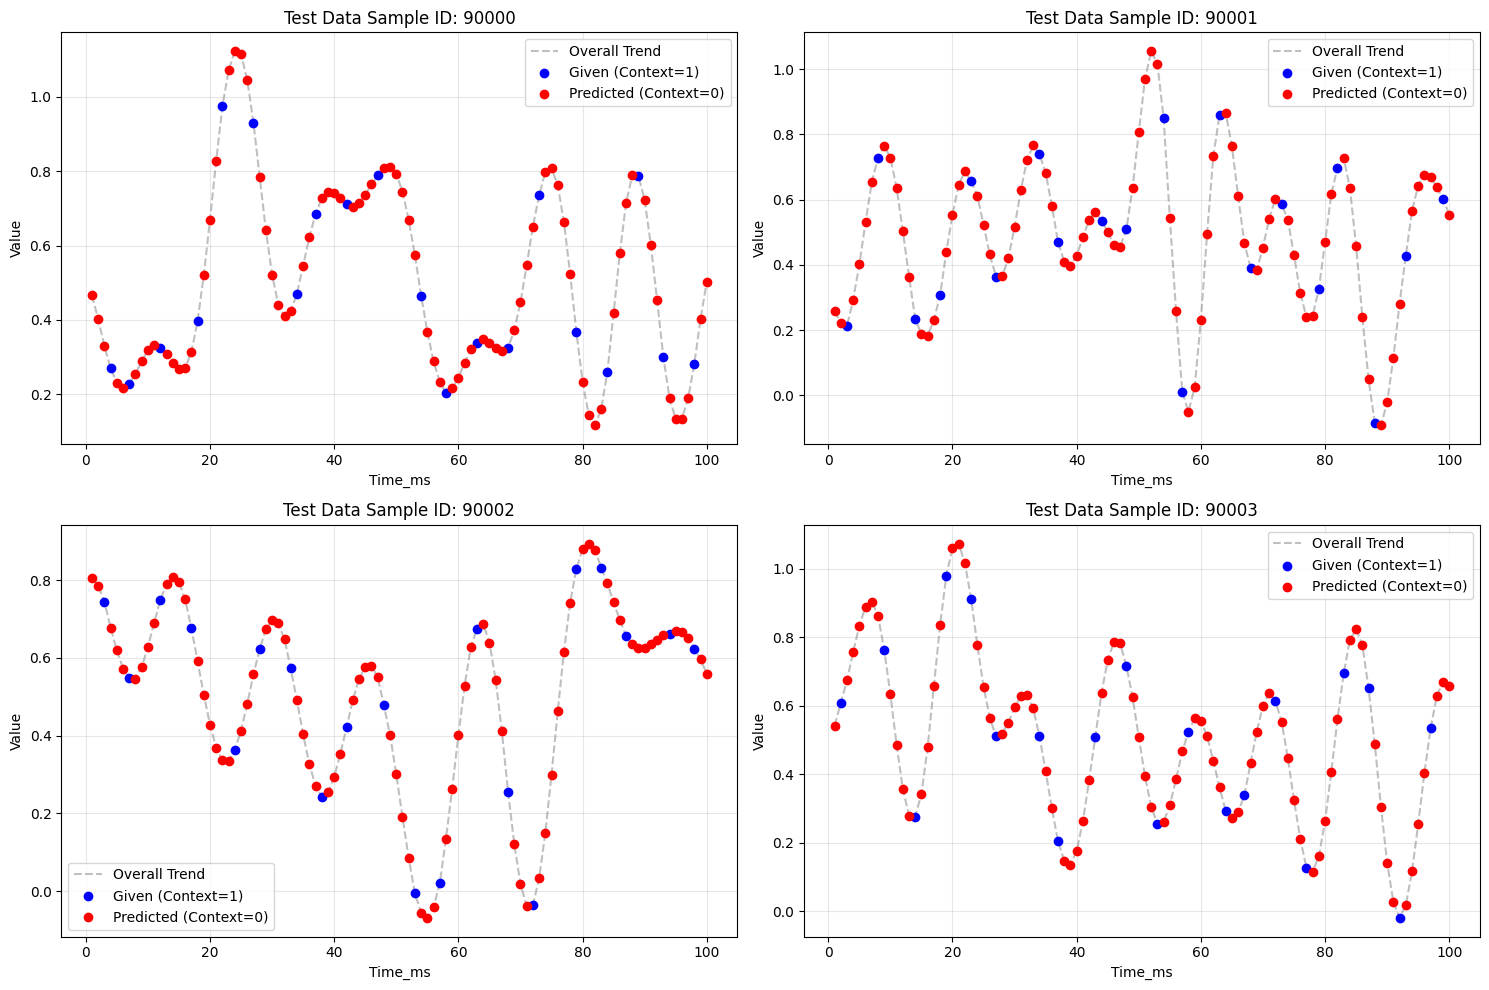

In [11]:
import matplotlib.pyplot as plt

print("Generating plots...")

# 1. Load the final submission you just created
submission_df = pd.read_csv('final_submission.csv')

# 2. Merge with test_df to get the 'Is_Context' column back for plotting purposes
# This allows us to know which points were given vs which were predicted
plot_df = submission_df.merge(test_df[['Sample_ID', 'Time_ms', 'Is_Context']], on=['Sample_ID', 'Time_ms'])

# 3. Select the first 4 unique Sample_IDs to visualize
sample_ids_to_plot = plot_df['Sample_ID'].unique()[:4]

plt.figure(figsize=(15, 10))

for i, sample_id in enumerate(sample_ids_to_plot, 1):
    plt.subplot(2, 2, i)
    
    # Get data for this specific sample
    sample_data = plot_df[plot_df['Sample_ID'] == sample_id]
    
    # Separate context (given) and predicted (missing) points
    context_points = sample_data[sample_data['Is_Context'] == 1]
    predicted_points = sample_data[sample_data['Is_Context'] == 0]
    
    # Plot a line connecting all points to show the overall continuous waveform/trend
    plt.plot(sample_data['Time_ms'], sample_data['Value'], color='gray', linestyle='--', alpha=0.5, label='Overall Trend')
    
    # Scatter plot the given context points (Blue)
    plt.scatter(context_points['Time_ms'], context_points['Value'], color='blue', label='Given (Context=1)', zorder=5)
    
    # Scatter plot the predicted points (Red)
    plt.scatter(predicted_points['Time_ms'], predicted_points['Value'], color='red', label='Predicted (Context=0)', zorder=5)
    
    plt.title(f'Test Data Sample ID: {sample_id}')
    plt.xlabel('Time_ms')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()